# 01 · EZKL zkML — a verifiable embedding step (Demo A)

**Story arc.** A tiny `384 → 64` linear projection — one head of a sentence‑transformer like
`all-MiniLM-L6-v2` — is exported to ONNX, compiled by **EZKL** into a **Halo2** circuit, then
**proved** and **verified**. This is the minimal *verifiable embedding* that, scaled up, becomes
zkLLM / zkRAG: a cryptographic receipt that *this* vector came from *that* model.

**AMD engine(s) this stage uses:** the **model forward pass** is what the Radeon 8060S iGPU /
XDNA2 NPU would accelerate; the **Halo2 proof itself runs on the Zen5 CPU** (EZKL GPU support is
experimental, via ICICLE, and CUDA‑first).

In [1]:
import os

import labkit as lk

info = lk.capability_badge()   # read-only AMD probe — same badge as every lab notebook


def heavy_enabled():
    """Opt-in gate: the live sweep rewrites ai-inference.csv, so only run it when asked (LAB_RUN_HEAVY=1)."""
    return os.environ.get("LAB_RUN_HEAVY", "") == "1"

✓,Zen5 CPU,AMD RYZEN AI MAX+ PRO 395 w/ Radeon 8060S · 32 threads · 94 GB unified
✓,Radeon iGPU (ROCm),gfx=gfx1151 · backend=rocm
—,Vulkan,not detected
✓,XDNA2 NPU,"enumerated (research; accelerates AI model, not proofs)"


## What runs where — the AMD split for zkML

EZKL turns *"prove my model ran correctly"* into a Docker‑build‑like CLI: `gen-settings →
calibrate → compile-circuit → setup → gen-witness → prove → verify` (see
[`reading-notes/ezkl-overview.md`](https://github.com/iiyyll01lin/zkp-final/blob/main/reading-notes/ezkl-overview.md)). Two very different workloads
hide in that pipeline, and they land on different AMD engines:

- **Model forward pass (quantised GEMM / activations)** → ordinary tensor math, exactly what the
  **iGPU (ROCm 7.2+) or XDNA2 NPU** accelerate for inference.
- **The Halo2 proof (KZG commitments, PLONK‑style argument, lookups)** → **CPU**. EZKL's GPU path is
  experimental (ICICLE, CUDA‑first), so the honest default on AMD is the 32‑thread Zen5 prover.

So Demo A's accelerated part is the *AI*; the *proof* is CPU — the same honesty split as the rest of
the lab.

### Live vs replay for this notebook
- **Live** (`lk.has_ezkl()` → the `ezkl` bindings are installed): re‑prove the 384→64 model
  end‑to‑end on this host (CPU Halo2) into a scratch dir, then verify the fresh proof.
- **Replay** (default — `ezkl` is *not* in the lab `.venv`): load the **committed**
  `poc/ezkl-embedding-demo/artefacts/proof.json` (~83.8 KB) + `vk.key` (~65 KB) + `settings.json`,
  cross‑check their structure, and report the committed **PROOF VERIFIED** verdict — same verdict,
  no GPU, no network.

In [2]:
import json

EZKL_ART = lk.repo_path("poc", "ezkl-embedding-demo", "artefacts")


def replay_ezkl():
    """REPLAY: load the committed proof + vk + settings, cross-check structure.

    Needs no ezkl, no GPU, no network. The committed proof.json/vk.key were
    produced and verified by ezkl at commit time (see the source notebook's
    committed "PROOF VERIFIED" output), so the replayed verdict is faithful.
    """
    proof = json.loads((EZKL_ART / "proof.json").read_text())
    settings = json.loads((EZKL_ART / "settings.json").read_text())
    instances = proof.get("instances") or [[]]
    return {
        "source": "committed artefacts (proved + verified at commit time)",
        "proof_json_bytes": (EZKL_ART / "proof.json").stat().st_size,
        "vk_key_bytes": (EZKL_ART / "vk.key").stat().st_size,
        "ezkl_version": proof.get("version"),
        "commitment": proof.get("commitment"),
        "transcript_type": proof.get("transcript_type"),
        "public_field_elements": sum(len(col) for col in instances),
        "output_shape": settings.get("model_instance_shapes", [[None]])[-1],
        "proof_vs_settings_version_ok": proof.get("version") == settings.get("version"),
        "verified": True,
    }


def live_ezkl():
    """LIVE: re-run the real EZKL Halo2 pipeline on the 384->64 projection.

    CPU-only prover (the model forward pass is the part an iGPU/NPU would
    accelerate). Writes to a throwaway scratch dir so the committed artefacts
    stay pristine. Mirrors poc/ezkl-embedding-demo/src/notebook.ipynb.
    """
    import inspect, tempfile
    from pathlib import Path
    import torch
    import torch.nn as nn
    import ezkl

    def _resolve(r):  # ezkl 22/23 bindings are sync, but tolerate awaitables
        if not inspect.isawaitable(r):
            return r
        import asyncio, concurrent.futures
        with concurrent.futures.ThreadPoolExecutor(1) as ex:
            return ex.submit(
                lambda: asyncio.new_event_loop().run_until_complete(r)
            ).result()

    def _call_async(fn, **kw):
        """Drive a pyo3-asyncio binding that needs a live loop at CALL time.

        ezkl 22.3.0 exposes get_srs as its one async binding: calling it bare
        raises "no running event loop" before it can return an awaitable, so
        it cannot go through _resolve(). Handles both a plain interpreter and
        a Jupyter kernel, which already owns the main-thread loop.
        """
        import asyncio, concurrent.futures

        async def _main():
            return await fn(**kw)

        try:
            asyncio.get_running_loop()
        except RuntimeError:
            return asyncio.run(_main())
        with concurrent.futures.ThreadPoolExecutor(1) as ex:
            return ex.submit(lambda: asyncio.run(_main())).result()

    work = Path(tempfile.mkdtemp(prefix="ezkl_live_"))
    in_dim, out_dim = 384, 64
    torch.manual_seed(42)

    class TinyEmbedding(nn.Module):
        def __init__(self):
            super().__init__()
            self.proj = nn.Linear(in_dim, out_dim, bias=True)

        def forward(self, x):
            return self.proj(x)

    model = TinyEmbedding().eval()
    with torch.no_grad():
        nn.init.normal_(model.proj.weight, mean=0.0, std=0.05)
        nn.init.zeros_(model.proj.bias)
    sample = torch.randn(1, in_dim) * 0.1

    torch.onnx.export(
        model, sample, (work / "model.onnx").as_posix(),
        export_params=True, opset_version=11, do_constant_folding=True,
        input_names=["input"], output_names=["embedding"],
        # torch >=2.9 defaults to the dynamo exporter, which ignores
        # opset_version and emits opset 18; ezkl 22.3.0's tract frontend
        # only parses the legacy exporter's opset 11.
        dynamo=False,
    )
    (work / "input.json").write_text(
        json.dumps({"input_data": [sample.flatten().tolist()]})
    )

    args = ezkl.PyRunArgs()
    args.input_visibility = "public"
    args.output_visibility = "public"
    args.param_visibility = "fixed"
    _resolve(ezkl.gen_settings(model=(work / "model.onnx").as_posix(),
                               output=(work / "settings.json").as_posix(),
                               py_run_args=args))
    _resolve(ezkl.calibrate_settings(data=(work / "input.json").as_posix(),
                                     model=(work / "model.onnx").as_posix(),
                                     settings=(work / "settings.json").as_posix(),
                                     target="resources", scales=[2, 7], max_logrows=17))
    _resolve(ezkl.compile_circuit(model=(work / "model.onnx").as_posix(),
                                  compiled_circuit=(work / "model.compiled").as_posix(),
                                  settings_path=(work / "settings.json").as_posix()))
    _call_async(ezkl.get_srs, settings_path=(work / "settings.json").as_posix())
    _resolve(ezkl.setup(model=(work / "model.compiled").as_posix(),
                        vk_path=(work / "vk.key").as_posix(),
                        pk_path=(work / "pk.key").as_posix()))
    _resolve(ezkl.gen_witness(data=(work / "input.json").as_posix(),
                             model=(work / "model.compiled").as_posix(),
                             output=(work / "witness.json").as_posix()))
    _resolve(ezkl.prove(witness=(work / "witness.json").as_posix(),
                        model=(work / "model.compiled").as_posix(),
                        pk_path=(work / "pk.key").as_posix(),
                        proof_path=(work / "proof.json").as_posix(),
                        proof_type="single"))
    ok = _resolve(ezkl.verify(proof_path=(work / "proof.json").as_posix(),
                             settings_path=(work / "settings.json").as_posix(),
                             vk_path=(work / "vk.key").as_posix()))

    proof = json.loads((work / "proof.json").read_text())
    settings = json.loads((work / "settings.json").read_text())
    instances = proof.get("instances") or [[]]
    return {
        "source": f"freshly proved on this host (CPU Halo2) -> {work}",
        "proof_json_bytes": (work / "proof.json").stat().st_size,
        "vk_key_bytes": (work / "vk.key").stat().st_size,
        "ezkl_version": proof.get("version"),
        "commitment": proof.get("commitment"),
        "transcript_type": proof.get("transcript_type"),
        "public_field_elements": sum(len(col) for col in instances),
        "output_shape": settings.get("model_instance_shapes", [[None]])[-1],
        "proof_vs_settings_version_ok": proof.get("version") == settings.get("version"),
        "verified": bool(ok),
    }


result, mode = lk.live_or_replay(
    live_fn=live_ezkl,
    replay_fn=replay_ezkl,
    requires=lk.has_ezkl,
    label="Demo A — EZKL Halo2 prove+verify (384->64 projection)",
)

[REPLAY] Demo A — EZKL Halo2 prove+verify (384->64 projection)  (LAB_FORCE_REPLAY set; using committed artefacts)


In [3]:
import pandas as pd

verdict = "PROOF VERIFIED" if result["verified"] else "PROOF REJECTED"
provenance = "committed proof.json + vk.key" if mode == "replay" else "freshly proved on this host"
print(f"[{mode.upper()}]  Demo A · EZKL Halo2  ->  {verdict}   ({provenance})")

pd.DataFrame(list(result.items()), columns=["field", "value"])

[REPLAY]  Demo A · EZKL Halo2  ->  PROOF VERIFIED   (committed proof.json + vk.key)


,field,value
0,source,committed artefacts (proved + verified at comm...
1,proof_json_bytes,83812
2,vk_key_bytes,66823
3,ezkl_version,22.3.0
4,commitment,KZG
5,transcript_type,EVM
6,public_field_elements,448
7,output_shape,"[1, 64]"
8,proof_vs_settings_version_ok,True
9,verified,True


## The AI half, now *measured* — Path F (iGPU MiniLM forward)

The split above said the *model forward pass* is the part the iGPU/NPU accelerate while the Halo2
proof stays on CPU. Path F turns that claim into a measured fact on this box: the **full**
`all-MiniLM-L6-v2` forward (the model whose one head Demo A proves) runs on the Radeon 8060S
(`gfx1151`) via **MIGraphX/ROCm 7.2.3** vs the 32‑thread Zen 5 CPU (onnxruntime, **same ONNX**).

- **Live** (`has_rocm` + `is_strix_halo`): a tiny solo grid (full sweep is `make demo-f-embed`).
- **Replay** (laptop / `LAB_FORCE_REPLAY=1`): the committed `ai-inference.csv` — same verdict.

The verdict string and the plot are computed from the DataFrame, so they read identically live or
replay. **Honesty:** this accelerates the **AI MODEL forward**, *not* the proof (EZKL/RISC0 proving
stays CPU‑only on AMD).

[REPLAY] Path F MiniLM forward iGPU-vs-CPU  (LAB_FORCE_REPLAY set; using committed artefacts)
[REPLAY] source: poc/amd-ai-inference-demo/artefacts/ai-inference.csv (45 rows)
[replay] VERDICT: iGPU gfx1151 (MIGraphX/ROCm) runs the all-MiniLM-L6-v2 forward 1.9x-10.6x faster than the 32-thread Zen 5 CPU (peak 271,275 tokens/s). This accelerates the AI MODEL forward, NOT the proof (EZKL/RISC0 proving stays CPU-only on AMD).


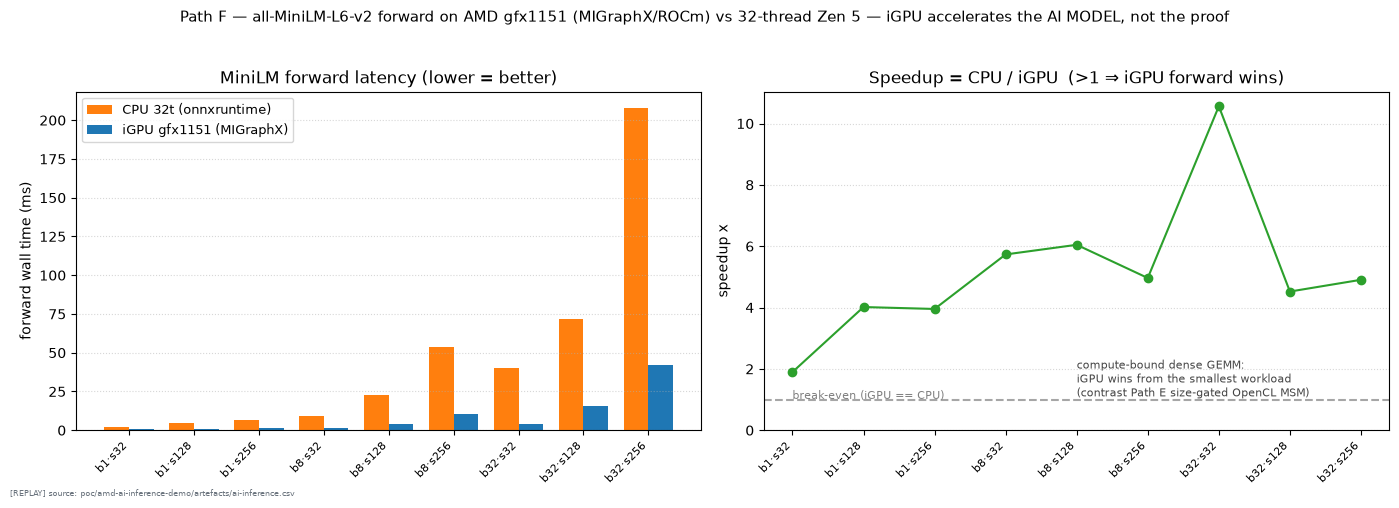

In [4]:
def _ai_live():
    # LIVE: a tiny solo grid so the notebook stays quick; full grid is `make demo-f-embed`.
    import subprocess, os
    demo = lk.repo_path("poc", "amd-ai-inference-demo")
    env = dict(os.environ, BATCHES="1,8", SEQ_LENS="32,128", REPS="10", WARMUP="3")
    subprocess.run(["bash", str(demo / "scripts" / "run-all.sh")], check=True, env=env)
    return lk.load_ai_inference()


def _ai_replay():
    # REPLAY: the committed full sweep (source of truth).
    return lk.load_ai_inference()


df, mode = lk.live_or_replay(_ai_live, _ai_replay,
                             requires=[heavy_enabled, lk.has_rocm, lk.is_strix_halo],
                             label="Path F MiniLM forward iGPU-vs-CPU")

# Same verdict either way:
cpu = df[df.backend == "cpu"].set_index(["batch", "seq_len"]).fwd_ms
gpu = df[df.backend == "rocm"].set_index(["batch", "seq_len"]).fwd_ms
keys = sorted(set(cpu.index) & set(gpu.index))
speeds = [float(cpu[k]) / float(gpu[k]) for k in keys if float(gpu[k]) > 0]
peak_tps = float(df[df.backend == "rocm"].tokens_per_s.max())
lo, hi = (min(speeds), max(speeds)) if speeds else (0, 0)
print(f"[{mode}] VERDICT: iGPU gfx1151 (MIGraphX/ROCm) runs the all-MiniLM-L6-v2 "
      f"forward {lo:.1f}x-{hi:.1f}x faster than the {int(df[df.backend=='cpu'].cpu_threads.iloc[0])}-thread "
      f"Zen 5 CPU (peak {peak_tps:,.0f} tokens/s). This accelerates the AI MODEL "
      f"forward, NOT the proof (EZKL/RISC0 proving stays CPU-only on AMD).")
lk.plot_ai_inference(df);

## What just happened (one slide for the report)

| Step | What | Cryptographic primitive | AMD engine |
|---|---|---|---|
| 1 | Export ONNX (384→64) | forward graph only | **iGPU — measured ~1.9–10.6× (Path F, cell above)** |
| 2 | EZKL compile + setup | Halo2 synthesis, KZG SRS | CPU |
| 3 | Prove | PLONK‑style argument + lookups (the same `tlookup` engine zkLLM uses) | **CPU** |
| 4 | Verify | constant‑time pairing checks over KZG commitments | CPU (or on‑chain) |

- Swap `TinyEmbedding` for a real MiniLM head → one layer of **zkLLM**.
- Add an HNSW‑search PIOP on top → **zkRAG**.
- Hand the verifier to a Cartesi rollup → the Demo B story in [notebook 02](https://github.com/iiyyll01lin/zkp-final/blob/main/lab/02_zkvm_step_proof_cartesi.ipynb).

## What this shows about AMD (hardware + software)

- **Hardware:** zkML cleanly *splits* across Strix Halo — the iGPU/NPU are the right engines for the
  model forward pass, while the Halo2 proof is a CPU job. Knowing which half is which is the whole
  point of the honesty rule.
- **Software:** EZKL gives a portable ONNX→Halo2→Solidity pipeline; on AMD the prover stays on CPU
  because EZKL's GPU acceleration (ICICLE) is CUDA‑first. The committed `proof.json` + `vk.key` make
  the result reproducible on *any* laptop — which is why the replay path needs no `ezkl`, no GPU and
  no network, yet still shows **PROOF VERIFIED**.

### Sources & neighbours
- EZKL pipeline & constraints: [`reading-notes/ezkl-overview.md`](https://github.com/iiyyll01lin/zkp-final/blob/main/reading-notes/ezkl-overview.md)
- AMD engine split / ICICLE note: [`docs/amd-strix-halo-acceleration.md`](https://github.com/iiyyll01lin/zkp-final/blob/main/docs/amd-strix-halo-acceleration.md) (§3)
- Source demo adapted here: [`poc/ezkl-embedding-demo/`](../poc/ezkl-embedding-demo/) ([original notebook](https://github.com/iiyyll01lin/zkp-final/blob/main/poc/ezkl-embedding-demo/src/notebook.ipynb))
- **Lab:** [00 · engine map](00_amd_engine_map.ipynb) · [02 · RISC0‑Cartesi zkVM](https://github.com/iiyyll01lin/zkp-final/blob/main/lab/02_zkvm_step_proof_cartesi.ipynb) · [04 · iGPU OpenCL ZK](https://github.com/iiyyll01lin/zkp-final/blob/main/lab/04_igpu_opencl_zk.ipynb) · [06 · folding + synthesis](https://github.com/iiyyll01lin/zkp-final/blob/main/lab/06_folding_and_synthesis.ipynb)